In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
uploaded = files.upload()

Saving hospital_readmissions_30k.csv to hospital_readmissions_30k (1).csv


In [ ]:
df = pd.read_csv("hospital_readmissions_30k.csv")

df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [ ]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["readmitted_30_days"].value_counts())

Dataset shape: (30000, 12)

Missing values:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64

Target distribution:
readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64


In [ ]:
df = df.drop("patient_id", axis=1)

In [ ]:
X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=2000,
    class_weight="balanced"
)

In [ ]:
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.5230


In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob,
    pos_label="Yes"
)

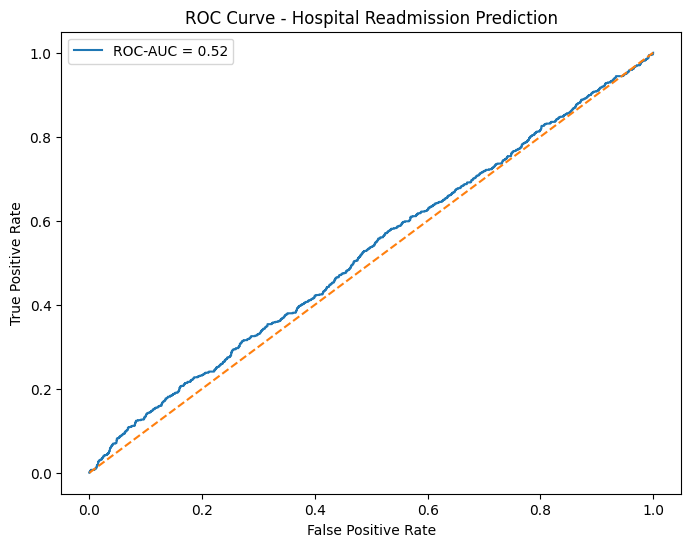

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5552

Confusion Matrix:
[[2999 2266]
 [ 403  332]]

Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.57      0.69      5265
         Yes       0.13      0.45      0.20       735

    accuracy                           0.56      6000
   macro avg       0.50      0.51      0.45      6000
weighted avg       0.79      0.56      0.63      6000

